# Fluency Classification Model — speechocean762

**Task 6 of SpeakReady.** Trains a real ML classifier that predicts a
speaker's fluency tier (Beginner / Intermediate / Fluent) from acoustic and
linguistic features of a transcribed spoken answer, so `src/scorer.py` no
longer needs a placeholder.

**Dataset:** [`mispeech/speechocean762`](https://huggingface.co/datasets/mispeech/speechocean762)
— 5,000 English utterances read aloud by 250 non-native (Mandarin L1)
speakers, ages 5-43, with expert-annotated pronunciation scores including a
0-10 **fluency** score per utterance. It ships with a fixed 2,500/2,500
train/test split, which we use as-is (no reshuffling) so results are
comparable to other work on this dataset.

**Pipeline:** dataset → local Whisper transcription (word timestamps) →
`src.features.extract_features` → 3-class label → train/tune/evaluate
Logistic Regression, Random Forest, and XGBoost against a majority-class
baseline → save the best model.


## 1. Setup

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from datasets import Audio, load_dataset
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import joblib

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.features import FEATURE_NAMES, extract_features
from src.scorer import LabelDecodingClassifier
from src.speech import Transcript, Word
from scripts.transcribe_speechocean762 import transcribe_split, CACHE_DIR

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 20)


## 2. Load and explore the dataset

We load both splits and decode audio lazily (`decode=False` + manual
`soundfile` decode) to avoid an optional `torchcodec`/FFmpeg dependency that
isn't reliably installable on every platform.


In [2]:
raw = load_dataset("mispeech/speechocean762")
raw = raw.cast_column("audio", Audio(decode=False))
raw


DatasetDict({
    train: Dataset({
        features: ['accuracy', 'completeness', 'fluency', 'prosodic', 'text', 'total', 'words', 'speaker', 'gender', 'age', 'audio'],
        num_rows: 2500
    })
    test: Dataset({
        features: ['accuracy', 'completeness', 'fluency', 'prosodic', 'text', 'total', 'words', 'speaker', 'gender', 'age', 'audio'],
        num_rows: 2500
    })
})

In [3]:
train_df = raw["train"].remove_columns(["audio", "words"]).to_pandas()
test_df = raw["test"].remove_columns(["audio", "words"]).to_pandas()
train_df["split"] = "train"
test_df["split"] = "test"
meta_df = pd.concat([train_df, test_df], ignore_index=True)
meta_df.head()


,accuracy,completeness,fluency,prosodic,text,total,speaker,gender,age,split
0,8,10.0,9,9,WE CALL IT BEAR,8,0001,m,6,train
1,8,10.0,9,9,ZERO THREE FIVE ONE,8,0001,m,6,train
2,9,10.0,10,10,THREE TWO TWO SEVEN,9,0001,m,6,train
3,10,10.0,9,9,ELEPHANTS TAI GOOSE,9,0001,m,6,train
4,9,10.0,9,10,TOM GIVES UP BOXING,9,0001,m,6,train


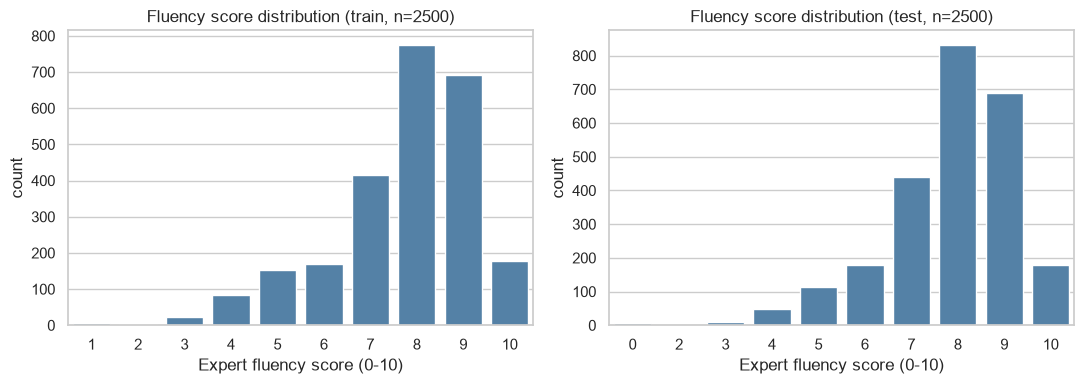

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, split in zip(axes, ["train", "test"]):
    subset = meta_df[meta_df["split"] == split]
    sns.countplot(x="fluency", data=subset, color="steelblue", ax=ax)
    ax.set_title(f"Fluency score distribution ({split}, n={len(subset)})")
    ax.set_xlabel("Expert fluency score (0-10)")
plt.tight_layout()
plt.show()


In [5]:
print("Fluency score summary (train):")
print(meta_df[meta_df.split == "train"]["fluency"].describe())
print()
print("Speaker age range:", meta_df["age"].min(), "-", meta_df["age"].max())
print("Gender counts:\n", meta_df["gender"].value_counts())


Fluency score summary (train):
count    2500.000000
mean        7.728400
std         1.555249
min         1.000000
25%         7.000000
50%         8.000000
75%         9.000000
max        10.000000
Name: fluency, dtype: float64

Speaker age range: 6 - 43
Gender counts:
 gender
m    2500
f    2500
Name: count, dtype: int64


## 3. Map the fluency score to 3 classes

The expert `fluency` score is 0-10 but very unevenly distributed (most
non-native readers in this dataset score fairly well). We bucket it into
three coaching-relevant tiers:

| Class | Raw fluency score | Rationale |
|---|---|---|
| **Beginner** | 0-5 | Noticeably halting/disfluent speech |
| **Intermediate** | 6-7 | Generally fluent with some rough patches |
| **Fluent** | 8-10 | Smooth, confident delivery |

These thresholds follow the dataset's own scoring rubric (scores are already
integers 0-10 given by expert annotators), just regrouped into coarser tiers
that map onto actionable coaching feedback rather than a single fine-grained
number few users could act on.


fluency_class  Beginner  Intermediate  Fluent
split                                        
test                180           619    1701
train               270           584    1646


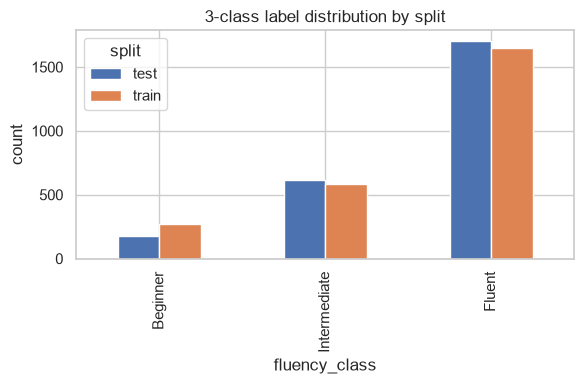

In [6]:
def to_fluency_class(score: int) -> str:
    if score <= 5:
        return "Beginner"
    elif score <= 7:
        return "Intermediate"
    return "Fluent"

meta_df["fluency_class"] = meta_df["fluency"].apply(to_fluency_class)

class_counts = (
    meta_df.groupby(["split", "fluency_class"]).size().unstack(fill_value=0)
    [["Beginner", "Intermediate", "Fluent"]]
)
print(class_counts)

class_counts.T.plot(kind="bar", figsize=(6, 4))
plt.title("3-class label distribution by split")
plt.ylabel("count")
plt.tight_layout()
plt.show()


## 4. Transcribe with local Whisper (faster-whisper)

We transcribe every utterance with **faster-whisper's `small` model running
locally** rather than Groq's hosted Whisper API. At 5,000 utterances this
would burn through Groq's free-tier rate limits fast, and word-level
timestamps for feature extraction don't need a hosted model.

Each utterance is transcribed once with `word_timestamps=True`, then cached
to `data/whisper_cache/{split}.jsonl` (gitignored, regenerable) so re-running
this notebook doesn't re-transcribe anything. The actual transcription job
(`scripts/transcribe_speechocean762.py`) parallelizes across CPU processes —
a single multi-threaded `small`-model instance is slow per utterance on a
laptop CPU, so N single-threaded worker processes run concurrently instead,
each writing results to the cache as they finish (safe to interrupt/resume).
Because it takes over an hour end-to-end for 5,000 short clips on CPU, it was
run ahead of time in the background; the cell below simply verifies the
cache is complete (and would resume/finish it if it weren't).


In [7]:
transcribe_split("train")
transcribe_split("test")


[train] 2500/2500 already cached, 0 remaining


[test] 2500/2500 already cached, 0 remaining


In [8]:
def load_transcripts(split: str) -> dict[int, dict]:
    path = CACHE_DIR / f"{split}.jsonl"
    out = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            out[row["idx"]] = row
    return out

train_transcripts = load_transcripts("train")
test_transcripts = load_transcripts("test")
print(f"train: {len(train_transcripts)} cached transcripts")
print(f"test: {len(test_transcripts)} cached transcripts")

example = train_transcripts[0]
print("\nExample hypothesis:", example["text"])
print("Reference text:", raw["train"][0]["text"])


train: 2500 cached transcripts
test: 2500 cached transcripts

Example hypothesis: We call it bear.
Reference text: WE CALL IT BEAR


## 5. Extract features with `src.features.extract_features`

We reuse the exact same `extract_features` function the live app calls at
inference time, by wrapping each cached Whisper transcript in the same
`Transcript`/`Word` dataclasses `src/speech.py` produces. This guarantees the
training features and production features can never drift apart.


In [9]:
def build_transcript(cached: dict) -> Transcript:
    words = [Word(word=w, start=s, end=e) for w, s, e in cached["words"]]
    return Transcript(
        text=cached["text"],
        words=words,
        duration_seconds=cached["duration"],
        language="en",
    )

def build_feature_frame(split: str, transcripts: dict[int, dict]) -> pd.DataFrame:
    subset = meta_df[meta_df["split"] == split].reset_index(drop=True)
    rows = []
    for idx, row in subset.iterrows():
        cached = transcripts.get(idx)
        if cached is None:
            continue
        transcript = build_transcript(cached)
        features = extract_features(transcript)
        features["fluency_class"] = row["fluency_class"]
        features["fluency_raw"] = row["fluency"]
        features["speaker"] = row["speaker"]
        rows.append(features)
    return pd.DataFrame(rows)

train_features = build_feature_frame("train", train_transcripts)
test_features = build_feature_frame("test", test_transcripts)
print(train_features.shape, test_features.shape)
train_features.head()


(2500, 13) (2500, 13)


,words_per_minute,pause_count,long_pause_count,mean_pause_duration,total_pause_ratio,filler_count,filler_rate,repetition_count,type_token_ratio,mean_sentence_length,fluency_class,fluency_raw,speaker
0,93.023256,0,0,0.0,0.0,0,0.0,0,1.00,4.0,Fluent,9,0001
1,17.492711,0,0,0.0,0.0,0,0.0,0,1.00,1.0,Fluent,9,0001
2,71.641791,0,0,0.0,0.0,0,0.0,1,0.75,4.0,Fluent,10,0001
3,54.233203,0,0,0.0,0.0,0,0.0,0,1.00,3.0,Fluent,9,0001
4,79.734219,0,0,0.0,0.0,0,0.0,0,1.00,4.0,Fluent,9,0001


In [10]:
X_train = train_features[list(FEATURE_NAMES)]
y_train = train_features["fluency_class"]
X_test = test_features[list(FEATURE_NAMES)]
y_test = test_features["fluency_class"]

X_train.describe().T


,count,mean,std,min,25%,50%,75%,max
words_per_minute,2500.0,101.686370,30.113934,16.181230,80.72835,102.670663,122.511489,211.640212
pause_count,2500.0,0.055600,0.275207,0.000000,0.00000,0.000000,0.000000,4.000000
long_pause_count,2500.0,0.000800,0.028279,0.000000,0.00000,0.000000,0.000000,1.000000
mean_pause_duration,2500.0,0.036121,0.178737,0.000000,0.00000,0.000000,0.000000,3.700000
total_pause_ratio,2500.0,0.006782,0.033994,0.000000,0.00000,0.000000,0.000000,0.410496
filler_count,2500.0,0.069200,0.266157,0.000000,0.00000,0.000000,0.000000,2.000000
filler_rate,2500.0,1.019946,4.077803,0.000000,0.00000,0.000000,0.000000,40.000000
repetition_count,2500.0,0.018000,0.172302,0.000000,0.00000,0.000000,0.000000,5.000000
type_token_ratio,2500.0,0.974442,0.067188,0.333333,1.00000,1.000000,1.000000,1.000000
mean_sentence_length,2500.0,6.427367,2.133722,1.000000,5.00000,6.000000,8.000000,18.000000


## 6. Baseline: majority-class classifier

Before training anything, we need a floor to beat. With classes this
imbalanced, a majority-class baseline can post deceptively high accuracy
while being useless — which is exactly why we report **macro F1** alongside
accuracy throughout this notebook.


In [11]:
baseline = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

results = {}
results["Baseline (majority class)"] = {
    "accuracy": accuracy_score(y_test, baseline_pred),
    "macro_f1": f1_score(y_test, baseline_pred, average="macro"),
}
print(json.dumps(results["Baseline (majority class)"], indent=2))
print(classification_report(y_test, baseline_pred, zero_division=0))


{
  "accuracy": 0.6804,
  "macro_f1": 0.2699357295881933
}
              precision    recall  f1-score   support

    Beginner       0.00      0.00      0.00       180
      Fluent       0.68      1.00      0.81      1701
Intermediate       0.00      0.00      0.00       619

    accuracy                           0.68      2500
   macro avg       0.23      0.33      0.27      2500
weighted avg       0.46      0.68      0.55      2500



## 7. Train and tune candidate models

We tune each model with 5-fold **stratified cross-validation on the train
split only**, optimizing macro F1 (accuracy alone would favor the majority
class). The held-out `test` split is touched exactly once per model, at
final evaluation.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
sample_weight_train = compute_sample_weight("balanced", y_train)

fitted_models = {}
cv_summary = {}

def tune(name, estimator, param_grid, y=None, fit_params=None):
    grid = GridSearchCV(estimator, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    grid.fit(X_train, y_train if y is None else y, **(fit_params or {}))
    fitted_models[name] = grid.best_estimator_
    cv_summary[name] = {"best_params": grid.best_params_, "cv_macro_f1": grid.best_score_}
    print(f"{name}: best_params={grid.best_params_}, cv_macro_f1={grid.best_score_:.4f}")
    return grid.best_estimator_


In [13]:
logreg_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
])
tune(
    "Logistic Regression",
    logreg_pipeline,
    {"clf__C": [0.01, 0.1, 1.0, 10.0]},
)


Logistic Regression: best_params={'clf__C': 0.01}, cv_macro_f1=0.6380


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Beginner','Fluent','Intermediate']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['words_per_minute','pause_count','long_pause_count',..., 'repetition_count','type_token_ratio','mean_sentence_length']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [14]:
tune(
    "Random Forest",
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    {
        "n_estimators": [200, 400],
        "max_depth": [None, 10, 20],
        "min_samples_leaf": [1, 3],
    },
)


Random Forest: best_params={'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 400}, cv_macro_f1=0.6488


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 

XGBoost's multiclass objective requires integer-encoded labels (unlike
scikit-learn's own classifiers, which accept strings directly). We fit it on
a `LabelEncoder`-encoded target, then immediately wrap it in
`src.scorer.LabelDecodingClassifier` so it exposes the same string-label
`predict`/`predict_proba`/`classes_` interface as the other models — this
also keeps the wrapper class importable from a stable module path, which
`joblib` needs to unpickle it later in `src/scorer.py` or in tests.


In [15]:
label_encoder = LabelEncoder().fit(y_train)
y_train_encoded = label_encoder.transform(y_train)

xgb_best = tune(
    "XGBoost",
    XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
    ),
    {
        "n_estimators": [150, 300],
        "max_depth": [3, 5],
        "learning_rate": [0.05, 0.1],
    },
    y=y_train_encoded,
    fit_params={"sample_weight": sample_weight_train},
)
fitted_models["XGBoost"] = LabelDecodingClassifier(xgb_best, label_encoder)


XGBoost: best_params={'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}, cv_macro_f1=0.6638


## 8. Evaluate every model on the held-out test split

Every fitted model now exposes the same string-label interface, so
evaluation doesn't need to special-case any of them.


In [16]:
for name, model in fitted_models.items():
    preds = model.predict(X_test)
    results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "macro_f1": f1_score(y_test, preds, average="macro"),
        "cv_macro_f1": cv_summary[name]["cv_macro_f1"],
        "best_params": cv_summary[name]["best_params"],
    }

results_df = pd.DataFrame(results).T[["accuracy", "macro_f1", "cv_macro_f1"]]
results_df.sort_values("macro_f1", ascending=False)


,accuracy,macro_f1,cv_macro_f1
Random Forest,0.7272,0.632855,0.648833
XGBoost,0.7236,0.618861,0.663759
Logistic Regression,0.7,0.597578,0.638048
Baseline (majority class),0.6804,0.269936,NaN


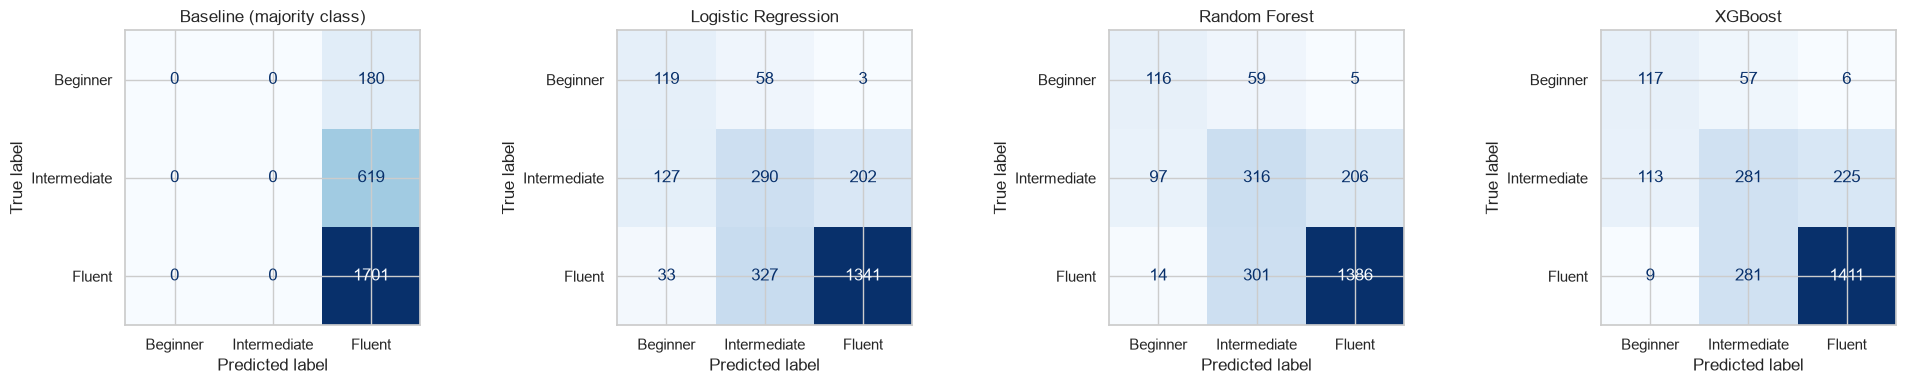

In [17]:
labels_order = ["Beginner", "Intermediate", "Fluent"]
all_models_for_cm = {"Baseline (majority class)": baseline, **fitted_models}

fig, axes = plt.subplots(1, len(all_models_for_cm), figsize=(5 * len(all_models_for_cm), 4))
for ax, (name, model) in zip(axes, all_models_for_cm.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds, labels=labels_order)
    ConfusionMatrixDisplay(cm, display_labels=labels_order).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 9. Feature importance


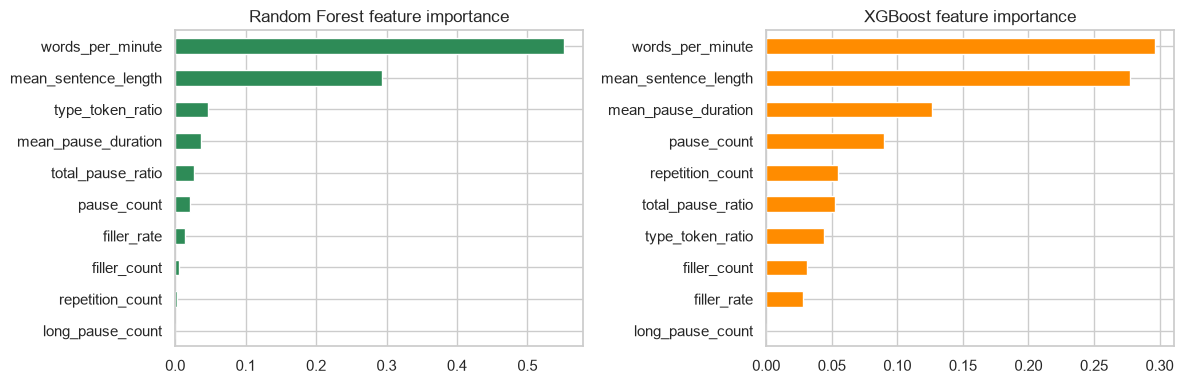

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

rf_importances = pd.Series(
    fitted_models["Random Forest"].feature_importances_, index=FEATURE_NAMES
).sort_values()
rf_importances.plot(kind="barh", ax=axes[0], color="seagreen")
axes[0].set_title("Random Forest feature importance")

xgb_importances = pd.Series(
    fitted_models["XGBoost"].inner.feature_importances_, index=FEATURE_NAMES
).sort_values()
xgb_importances.plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("XGBoost feature importance")

plt.tight_layout()
plt.show()


In [19]:
logreg = fitted_models["Logistic Regression"].named_steps["clf"]
coef_df = pd.DataFrame(logreg.coef_, index=logreg.classes_, columns=FEATURE_NAMES)
coef_df.T


,Beginner,Fluent,Intermediate
words_per_minute,-0.945077,0.892200,0.052877
pause_count,0.237643,-0.125265,-0.112378
long_pause_count,0.019182,-0.025175,0.005993
mean_pause_duration,-0.016981,-0.066686,0.083667
total_pause_ratio,0.009026,-0.010524,0.001498
filler_count,0.066893,-0.024310,-0.042583
filler_rate,-0.028730,0.003534,0.025196
repetition_count,-0.063118,0.047232,0.015887
type_token_ratio,-0.103359,0.063447,0.039911
mean_sentence_length,0.740098,-0.683570,-0.056528


## 10. Save the best model and metrics

We select the model with the highest **test macro F1** (ties broken by
cross-validated macro F1) and persist it plus a full metrics report that
`README.md`'s results section is generated from.


In [20]:
best_name = results_df["macro_f1"].idxmax()
best_model = baseline if best_name == "Baseline (majority class)" else fitted_models[best_name]
print("Best model:", best_name)

config.MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, config.FLUENCY_MODEL_PATH)
print("Saved to", config.FLUENCY_MODEL_PATH)


Best model: Random Forest
Saved to C:\Users\sathw\Documents\speakready\models\fluency_model.joblib


In [21]:
final_preds = best_model.predict(X_test)
report = classification_report(y_test, final_preds, output_dict=True, zero_division=0)
cm = confusion_matrix(y_test, final_preds, labels=labels_order).tolist()

metrics = {
    "dataset": "mispeech/speechocean762",
    "n_train": len(X_train),
    "n_test": len(X_test),
    "class_thresholds": {"Beginner": "0-5", "Intermediate": "6-7", "Fluent": "8-10"},
    "class_distribution_train": y_train.value_counts().to_dict(),
    "class_distribution_test": y_test.value_counts().to_dict(),
    "best_model": best_name,
    "models": results,
    "best_model_classification_report": report,
    "best_model_confusion_matrix": {"labels": labels_order, "matrix": cm},
    "feature_names": list(FEATURE_NAMES),
}

metrics_path = config.MODELS_DIR / "metrics.json"
with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, default=str)

print(json.dumps(metrics, indent=2, default=str))


{
  "dataset": "mispeech/speechocean762",
  "n_train": 2500,
  "n_test": 2500,
  "class_thresholds": {
    "Beginner": "0-5",
    "Intermediate": "6-7",
    "Fluent": "8-10"
  },
  "class_distribution_train": {
    "Fluent": 1646,
    "Intermediate": 584,
    "Beginner": 270
  },
  "class_distribution_test": {
    "Fluent": 1701,
    "Intermediate": 619,
    "Beginner": 180
  },
  "best_model": "Random Forest",
  "models": {
    "Baseline (majority class)": {
      "accuracy": 0.6804,
      "macro_f1": 0.2699357295881933
    },
    "Logistic Regression": {
      "accuracy": 0.7,
      "macro_f1": 0.5975781029070818,
      "cv_macro_f1": 0.6380480217597475,
      "best_params": {
        "clf__C": 0.01
      }
    },
    "Random Forest": {
      "accuracy": 0.7272,
      "macro_f1": 0.632854952563867,
      "cv_macro_f1": 0.6488326448291774,
      "best_params": {
        "max_depth": 10,
        "min_samples_leaf": 3,
        "n_estimators": 400
      }
    },
    "XGBoost": {
      "a

## 11. Conclusion & limitations

See `models/metrics.json` for the exact numbers and `README.md`'s
**Model results** section for the reported summary (generated from that
file, not restated by hand here to avoid the two drifting apart).

**Limitations:**
- speechocean762 is *read-aloud* speech (subjects read a fixed sentence
  aloud), not spontaneous interview answers. Fluency signals in free speech
  (self-correction, thinking pauses, filler words while formulating an
  answer) are different from — and often more varied than — fluency signals
  in reading a known sentence. This model should be treated as a reasonable
  starting point, not a validated measure of spontaneous-speech fluency.
- All speakers are non-native (Mandarin L1) children and adults reading
  English; SpeakReady's actual users may have different accent and fluency
  profiles than this training population.
- Transcripts come from `faster-whisper`'s `small` model, not the
  Groq-hosted `whisper-large-v3-turbo` used in production
  (`src/speech.py`). ASR errors specific to the `small` model (especially on
  child speakers and mispronunciations) propagate into the features.
